# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Lioneil Diyoel Trystan Tikupadang | 5054251037|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc)

sns.set_style("whitegrid")

In [4]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.

df = pd.read_csv("mushrooms.csv")
print("Shape:", df.shape)
df.head()

Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [5]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.

print("Jumlah baris dan kolom:", df.shape)
print()
df.info()

print()
print("Jumlah missing value standar (NaN) per kolom:")
print(df.isnull().sum())

print()
print("Jumlah nilai '?' per kolom:")
question_mark_counts = (df == "?").sum()
print(question_mark_counts[question_mark_counts > 0])

Jumlah baris dan kolom: (8124, 23)

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-abo

In [6]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.

unique_counts = df.nunique().sort_values(ascending=False)
print("Jumlah nilai unik pada setiap fitur:")
print(unique_counts)

print()
print("Fitur dengan hanya 1 nilai unik (tidak informatif):")
print(unique_counts[unique_counts == 1])

Jumlah nilai unik pada setiap fitur:
gill-color                  12
cap-color                   10
odor                         9
stalk-color-below-ring       9
spore-print-color            9
stalk-color-above-ring       9
habitat                      7
cap-shape                    6
population                   6
stalk-root                   5
ring-type                    5
stalk-surface-above-ring     4
veil-color                   4
stalk-surface-below-ring     4
cap-surface                  4
ring-number                  3
gill-attachment              2
class                        2
bruises                      2
gill-size                    2
gill-spacing                 2
stalk-shape                  2
veil-type                    1
dtype: int64

Fitur dengan hanya 1 nilai unik (tidak informatif):
veil-type    1
dtype: int64


class
e    4208
p    3916
Name: count, dtype: int64

Proporsi kelas:
class
e    0.518
p    0.482
Name: count, dtype: float64


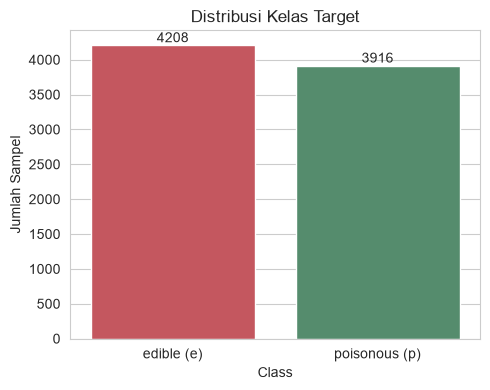

In [7]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

class_counts = df["class"].value_counts()
print(class_counts)
print()
print("Proporsi kelas:")
print((class_counts / len(df)).round(4))

plt.figure(figsize=(5, 4))
ax = sns.countplot(x="class", data=df, order=["e", "p"], hue="class", palette=["#4C956C", "#D64550"], legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["edible (e)", "poisonous (p)"])
ax.set_title("Distribusi Kelas Target")
ax.set_xlabel("Class")
ax.set_ylabel("Jumlah Sampel")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

class      e      p
odor               
a      1.000  0.000
c      0.000  1.000
f      0.000  1.000
l      1.000  0.000
m      0.000  1.000
n      0.966  0.034
p      0.000  1.000
s      0.000  1.000
y      0.000  1.000


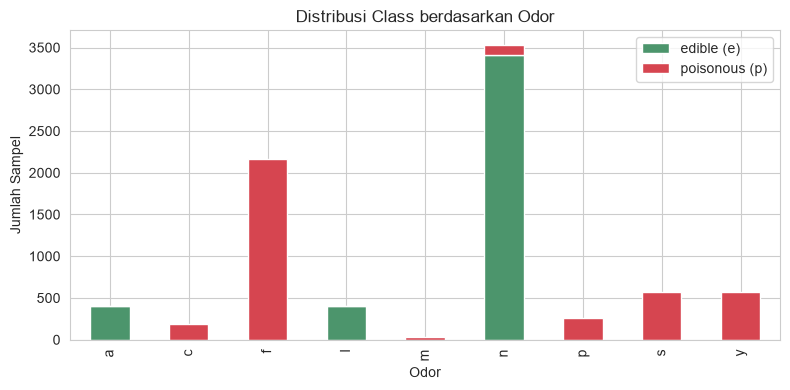


Proporsi nilai '?' pada stalk-root per kelas:
class
e    0.171
p    0.449
Name: missing_root, dtype: float64


In [8]:
# EDA tambahan: hubungan antara fitur 'odor' dengan kelas target,
# karena odor secara intuitif merupakan indikator kuat racun/tidaknya jamur.
odor_class = pd.crosstab(df["odor"], df["class"], normalize="index")
print(odor_class.round(3))

plt.figure(figsize=(8, 4))
pd.crosstab(df["odor"], df["class"]).plot(kind="bar", stacked=True, color=["#4C956C", "#D64550"], ax=plt.gca())
plt.title("Distribusi Class berdasarkan Odor")
plt.xlabel("Odor")
plt.ylabel("Jumlah Sampel")
plt.legend(["edible (e)", "poisonous (p)"])
plt.tight_layout()
plt.show()

# EDA tambahan: proporsi missing value ('?') pada stalk-root per kelas
missing_by_class = df.assign(missing_root=(df["stalk-root"] == "?")).groupby("class")["missing_root"].mean()
print()
print("Proporsi nilai '?' pada stalk-root per kelas:")
print(missing_by_class.round(3))


# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [9]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.

df["stalk-root"] = df["stalk-root"].replace("?", "missing")
print(df["stalk-root"].value_counts())


stalk-root
b          3776
missing    2480
e          1120
c           556
r           192
Name: count, dtype: int64


In [10]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.

single_value_cols = df.columns[df.nunique() == 1].tolist()
print("Fitur dengan 1 nilai unik yang akan di-drop:", single_value_cols)

df = df.drop(columns=single_value_cols)
print("Shape setelah drop:", df.shape)

Fitur dengan 1 nilai unik yang akan di-drop: ['veil-type']
Shape setelah drop: (8124, 22)


In [15]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df.drop(columns=["class"])
y = df["class"].map({"e": 0, "p": 1})

print("Distribusi target (0=edible, 1=poisonous):")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, stratify=y, random_state = 42 )

print()
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Proporsi kelas train:")
print(y_train.value_counts(normalize=True).round(4))
print("Proporsi kelas test:")
print(y_test.value_counts(normalize=True).round(4))

Distribusi target (0=edible, 1=poisonous):
class
0    4208
1    3916
Name: count, dtype: int64

Train shape: (6499, 21)  Test shape: (1625, 21)
Proporsi kelas train:
class
0    0.5179
1    0.4821
Name: proportion, dtype: float64
Proporsi kelas test:
class
0    0.5182
1    0.4818
Name: proportion, dtype: float64


In [16]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.

ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_ord = ordinal_encoder.fit_transform(X_train)
X_test_ord = ordinal_encoder.transform(X_test)

print("Contoh mapping kategori -> integer untuk fitur 'cap-shape':")
print(dict(zip(ordinal_encoder.categories_[0], range(len(ordinal_encoder.categories_[0])))))
print()
print("Shape hasil OrdinalEncoder - train:", X_train_ord.shape, " test:", X_test_ord.shape)

Contoh mapping kategori -> integer untuk fitur 'cap-shape':
{'b': 0, 'c': 1, 'f': 2, 'k': 3, 's': 4, 'x': 5}

Shape hasil OrdinalEncoder - train: (6499, 21)  test: (1625, 21)


In [18]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.

onehot_encoder = OneHotEncoder(handle_unknown="ignore")
X_train_ohe = onehot_encoder.fit_transform(X_train)
X_test_ohe = onehot_encoder.transform(X_test)

print("Shape hasil OneHotEncoder - train:", X_train_ohe.shape, " test:", X_test_ohe.shape)
print("Contoh nama kolom hasil encoding (10 pertama):")
print(onehot_encoder.get_feature_names_out()[:10])

Shape hasil OneHotEncoder - train: (6499, 116)  test: (1625, 116)
Contoh nama kolom hasil encoding (10 pertama):
['cap-shape_b' 'cap-shape_c' 'cap-shape_f' 'cap-shape_k' 'cap-shape_s'
 'cap-shape_x' 'cap-surface_f' 'cap-surface_g' 'cap-surface_s'
 'cap-surface_y']


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [19]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.

cnb_model = CategoricalNB()
cnb_model.fit(X_train_ord, y_train)
print(cnb_model)

CategoricalNB()


In [20]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_cnb = cnb_model.predict(X_test_ord)
y_proba_cnb = cnb_model.predict_proba(X_test_ord)[:, 1]

print("Contoh 10 prediksi pertama:", y_pred_cnb[:10])
print("Contoh 10 probabilitas kelas 1 pertama:", np.round(y_proba_cnb[:10], 3))

Contoh 10 prediksi pertama: [1 0 0 1 1 0 0 0 0 0]
Contoh 10 probabilitas kelas 1 pertama: [1.    0.369 0.    1.    1.    0.    0.    0.    0.    0.203]


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [21]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.

bnb_model = BernoulliNB()
bnb_model.fit(X_train_ohe, y_train)
print(bnb_model)

BernoulliNB()


In [22]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_bnb = bnb_model.predict(X_test_ohe)
y_proba_bnb = bnb_model.predict_proba(X_test_ohe)[:, 1]

print("Contoh 10 prediksi pertama:", y_pred_bnb[:10])
print("Contoh 10 probabilitas kelas 1 pertama:", np.round(y_proba_bnb[:10], 3))

Contoh 10 prediksi pertama: [1 0 0 1 1 0 0 0 0 0]
Contoh 10 probabilitas kelas 1 pertama: [1.    0.407 0.    1.    1.    0.    0.    0.    0.    0.068]


## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [23]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.

mnb_model = MultinomialNB()
mnb_model.fit(X_train_ohe, y_train)
print(mnb_model)

MultinomialNB()


In [24]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_mnb = mnb_model.predict(X_test_ohe)
y_proba_mnb = mnb_model.predict_proba(X_test_ohe)[:, 1]

print("Contoh 10 prediksi pertama:", y_pred_mnb[:10])
print("Contoh 10 probabilitas kelas 1 pertama:", np.round(y_proba_mnb[:10], 3))

Contoh 10 prediksi pertama: [1 0 0 1 1 0 0 0 0 0]
Contoh 10 probabilitas kelas 1 pertama: [1.    0.369 0.    1.    1.    0.    0.    0.    0.    0.203]


# 4. Evaluasi Model

In [25]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

results = {}
predictions = {
    "Categorical NB": y_pred_cnb,
    "Bernoulli NB": y_pred_bnb,
    "Multinomial NB": y_pred_mnb,
}

for name, y_pred in predictions.items():
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    }

results_df = pd.DataFrame(results).T.round(4)
results_df

,Accuracy,Precision,Recall,F1-Score
Categorical NB,0.9458,0.9901,0.8966,0.9410
Bernoulli NB,0.9329,0.9814,0.8774,0.9265
Multinomial NB,0.9458,0.9901,0.8966,0.9410


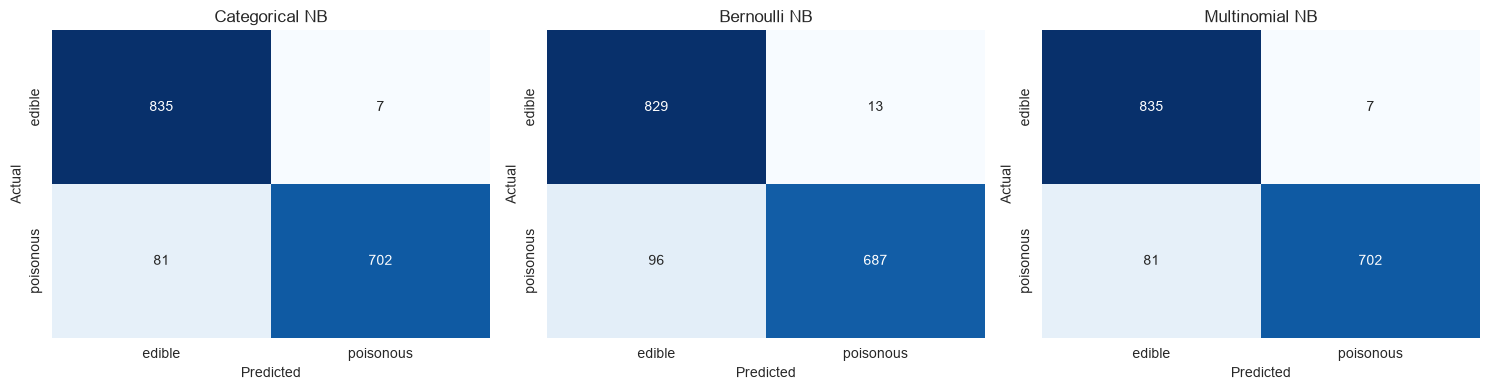

In [26]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["edible", "poisonous"],
                yticklabels=["edible", "poisonous"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

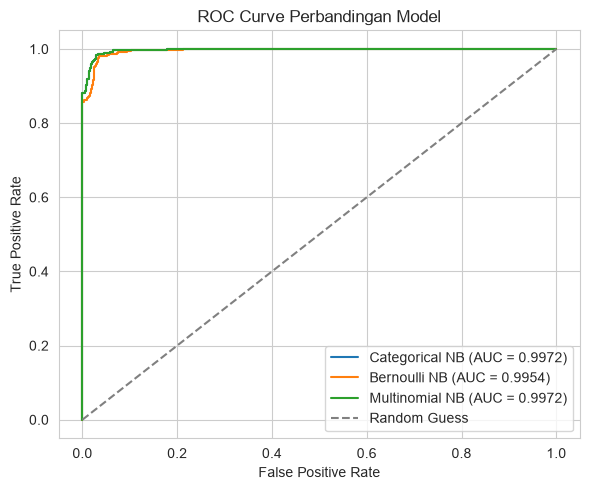

In [27]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.

probabilities = {
    "Categorical NB": y_proba_cnb,
    "Bernoulli NB": y_proba_bnb,
    "Multinomial NB": y_proba_mnb,
}

plt.figure(figsize=(6, 5))
for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Perbandingan Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.